In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
pd.options.display.float_format = '{:.2F}'.format

#Load & Examine

In [ ]:
sales = pd.read_csv('qSales_2024.csv')
display(sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
target_sales = sales.loc[sales['tic']=='TGT'].copy()
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


In [ ]:
target_sales['datadate'] = pd.to_datetime(target_sales['datadate'])

/tmp/ipykernel_2008/854237772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['datadate'] = pd.to_datetime(target_sales['datadate'])


#Visualize Patterns for Target

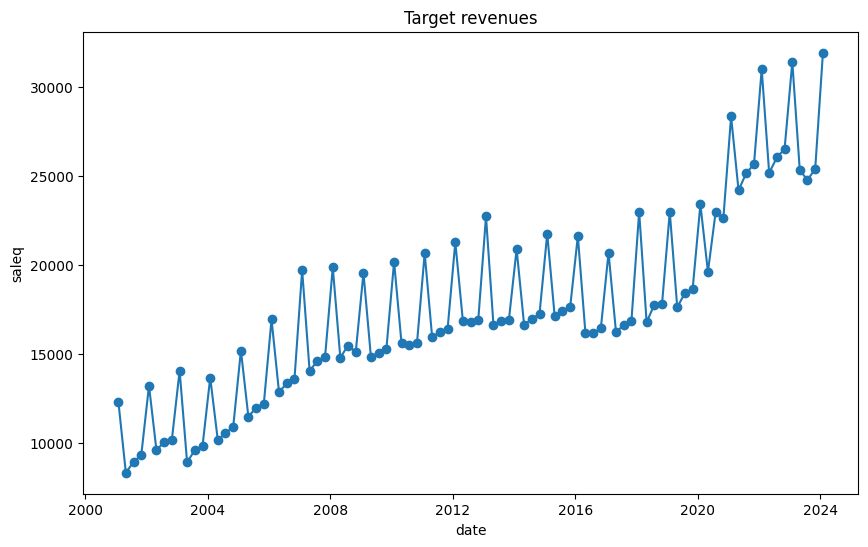

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Target revenues')
plt.xlabel('date')
plt.ylabel('saleq')

plt.plot(target_sales['datadate'], target_sales['saleq'], marker='o')

#Creating Time Variable

In [ ]:
#create new column called time, and it will be our independant variable
target_sales.loc[:, 'time'] = range(1, len(target_sales)+1)
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,summer_dv,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,0,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,0,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,0,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,1,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,0,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,0,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,0,92


In [ ]:
#splitting data into 75-25
#this code tells python to take the first 75%
dt4training = target_sales[:int(0.75 * len(target_sales))]

#this code tells python to take everything after the 75% above
dt4testing = target_sales[int(0.75 * len(target_sales)):]

In [ ]:
#dependant variable
y = dt4training.loc[:,'saleq']
#independant variable
x = dt4training.loc[:,['time']]
x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()
model1.params

,0
const,10503.75
time,139.30


In [ ]:
x_test = dt4testing.loc[:,['time']]
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
161,20254.51
162,20393.81
163,20533.11
164,20672.40
165,20811.70
166,20951.00
167,21090.29
168,21229.59
169,21368.89
170,21508.18


In [ ]:
prediction_results = model1.get_prediction(x_test)
prediction_results.summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,20254.51,572.33,19513.74,20995.29,17122.35,23386.68
162,20393.81,584.73,19636.99,21150.63,17257.82,23529.80
163,20533.11,597.20,19760.14,21306.08,17393.18,23673.04
164,20672.40,609.75,19883.19,21461.62,17528.44,23816.37
165,20811.70,622.38,20006.15,21617.25,17663.59,23959.81
166,20951.00,635.07,20129.02,21772.98,17798.64,24103.35
167,21090.29,647.82,20251.81,21928.78,17933.60,24246.99
168,21229.59,660.63,20374.52,22084.66,18068.45,24390.73
169,21368.89,673.50,20497.16,22240.61,18203.20,24534.58
170,21508.18,686.43,20619.73,22396.64,18337.85,24678.52


#Adding Dummy Variables for Summer Quarter (highest revenue), and Winter Quarter (second highest)

In [ ]:
target_sales.loc[:, 'summer_dv'] = np.where(target_sales['fqtr']==4, 1, 0)
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,summer_dv,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,0,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,0,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,0,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,1,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,0,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,0,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,0,92


In [ ]:
target_sales.loc[:, 'winter_dv'] = np.where(target_sales['fqtr']==2, 1, 0)
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,summer_dv,time,summer_dinteraction,winter_dv
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,0,2,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,0,3,0,1
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,0,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,1,5,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,1,89,89,0
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,0,90,0,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,0,91,0,1
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,0,92,0,0


In [ ]:
target_sales.loc[:, 'summer_dinteraction'] = target_sales['time'] * target_sales['summer_dv']
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,summer_dv,time,summer_dinteraction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,0,2,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,0,3,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,0,4,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,1,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,1,89,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,0,90,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,0,91,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,0,92,0


In [ ]:
target_sales.loc[:, 'winter_dinteraction'] = target_sales['time'] * target_sales['winter_dv']
display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,summer_dv,time,summer_dinteraction,winter_dv,winter_dinteraction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,...,USD,2000Q4,2000Q4,12324.00,A,1,1,1,0,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,...,USD,2001Q1,2001Q1,8334.00,A,0,2,0,0,0
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,...,USD,2001Q2,2001Q2,8941.00,A,0,3,0,1,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,...,USD,2001Q3,2001Q3,9331.00,A,0,4,0,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,...,USD,2001Q4,2001Q4,13220.00,A,1,5,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,...,USD,2022Q4,2022Q4,31395.00,A,1,89,89,0,0
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,...,USD,2023Q1,2023Q1,25322.00,A,0,90,0,0,0
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,...,USD,2023Q2,2023Q2,24773.00,A,0,91,0,1,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,...,USD,2023Q3,2023Q3,25398.00,A,0,92,0,0,0


In [ ]:
dt4training = target_sales[:int(0.75 * len(target_sales))]
dt4testing = target_sales[int(0.75 * len(target_sales)):]

In [ ]:
x = dt4training.loc[:,['time', 'summer_dv', 'summer_dinteraction','winter_dv','winter_dinteraction']]
x = sm.add_constant(x)

y = dt4training.loc[:,['saleq']]

model_dummy = sm.OLS(y,x).fit()
model_dummy.params

,0
const,9400.42
time,136.09
summer_dv,4077.03
summer_dinteraction,14.33
winter_dv,210.90
winter_dinteraction,-3.59


Target Revenue = 9400.42 + 136.09 * time + 4077.03 * summer_dv + 14.33 * summer_dinteraction + 210.90 * winter_dv - 3.59 * winter_dinteraction

In [ ]:
x_test = dt4testing.loc[:,['time', 'summer_dv', 'summer_dinteraction','winter_dv','winter_dinteraction']]
x_test = sm.add_constant(x_test)

model_dummy.get_prediction(x_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,18926.99,427.19,18373.73,19480.26,17255.21,20598.78
162,19019.07,617.93,18218.77,19819.38,17250.11,20788.04
163,19199.18,445.88,18621.70,19776.66,17519.23,20879.13
164,24458.49,599.01,23682.70,25234.28,22700.48,26216.50
165,19471.37,464.80,18869.39,20073.35,17782.84,21159.90
166,19549.09,671.52,18679.38,20418.79,17747.66,21350.51
167,19743.56,483.92,19116.82,20370.30,18046.05,21441.07
168,25060.19,648.12,24220.79,25899.59,23273.20,26847.18
169,20015.75,503.21,19364.02,20667.47,18308.85,21722.64
170,20079.10,726.16,19138.63,21019.57,18242.47,21915.74


From the above, we get the 80% confidence intervals for predicted sales revenue - the last two columns show us the range that Python is 80% sure teh revenue will fall within

In [ ]:
x_test_model1 = dt4testing.loc[:,['time']]
x_test_model1 = sm.add_constant(x_test_model1)

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_sales'] = model1.predict(x_test_model1)
model1_assessment['pct_error'] = abs((model1_assessment['saleq'] - model1_assessment['model1_predicted_sales']
                                  )/model1_assessment['saleq'])

display(model1_assessment)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,summer_dv,time,summer_dinteraction,winter_dv,winter_dinteraction,model1_predicted_sales,pct_error
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,2018Q1,16781.00,A,0,70,0,0,0,20254.51,0.21
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,2018Q2,17777.00,A,0,71,0,1,71,20393.81,0.15
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,2018Q3,17821.00,A,0,72,0,0,0,20533.11,0.15
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,2018Q4,22977.00,A,1,73,73,0,0,20672.40,0.10
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,2019Q1,17627.00,A,0,74,0,0,0,20811.70,0.18
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,2019Q2,18422.00,A,0,75,0,1,75,20951.00,0.14
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,2019Q3,18664.00,A,0,76,0,0,0,21090.29,0.13
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,2019Q4,23399.00,A,1,77,77,0,0,21229.59,0.09
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,2020Q1,19615.00,A,0,78,0,0,0,21368.89,0.09
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,2020Q2,22975.00,A,0,79,0,1,79,21508.18,0.06


In [ ]:
model1_assessment['pct_error'].mean()

np.float64(0.13987910103254483)

#Actual VS Predicted

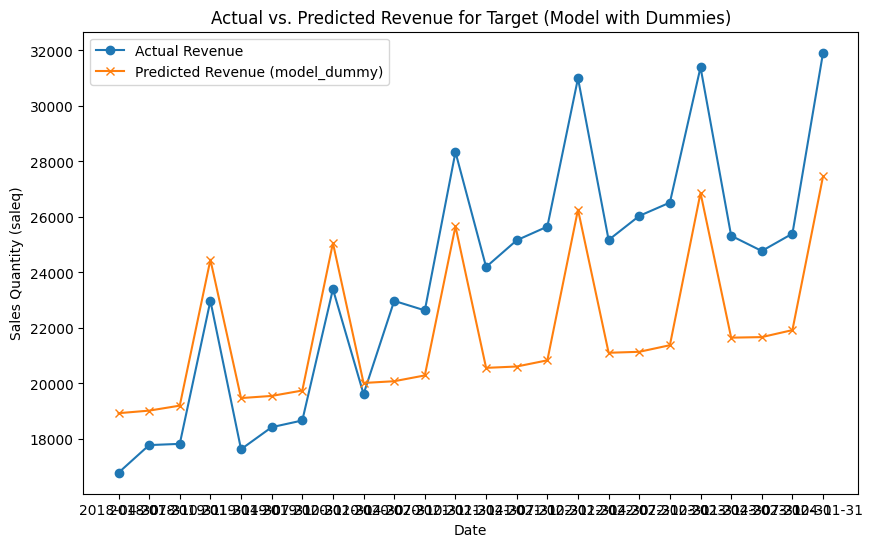

In [ ]:
model_dummy_predictions = model_dummy.get_prediction(x_test).summary_frame(alpha=0.2)

plt.figure(figsize=(10, 6))
plt.title('Actual vs. Predicted Revenue for Target (Model with Dummies)')
plt.xlabel('Date')
plt.ylabel('Sales Quantity (saleq)')

plt.plot(dt4testing['datadate'], dt4testing['saleq'], label='Actual Revenue', marker='o')
plt.plot(dt4testing['datadate'], model_dummy_predictions['mean'], label='Predicted Revenue (model_dummy)', marker='x')

plt.legend()
plt.show()

## Memo to Chapman Wealth Management

 The analysis of Target's sales patterns reveals significant seasonal influences and a consistent growth trend over the years.
 The model created incorporated summer_dv (FQ4) and winter_dv (FQ2) as dummy variables, which effectively capture the substantial revenue spikes during the holiday season (FQ4) and the moderately strong spring/early summer period (FQ2)

 These variables, combined with the independant variable of time, provided an explanation of Target's revenue. Visually, the model's predictions closely resemble actual sales, reflecting both the long-term growth (While not as steap, it still follows that increasing trend) and the quarterly fluctuations.

 While the initial model (without dummies) had a mean percentage error of approximately 14%, the dummy variable model improves this fit, demonstrating strong explanatory power for Target's revenue patterns.

Target's revenue is primarily driven by seasonality, making holiday quarter performance (FQ4) a critical indicator. The consistent underlying growth suggests good business, but understanding seasonal effects is essential for interpreting quarterly results; for instance, a Q1 dip after a strong Q4 is a normal pattern, not an obvious sign of weakness.

Our model assists in forecasting future revenue, helping investors assess earnings potential and make informed decisions by highlighting the predictable, yet impactful, seasonal variations in Target's sales performance.